In [1]:
import os
from pathlib import Path

os.environ.setdefault("JAX_PLATFORMS", "cpu")

import braincell
import brainunit as u
from braincell import Branch, Morpho
from develop_doc.helper import (
    branch_to_df,
    dict_to_df,
    morpho_branches_df,
    morpho_compare_df,
    morpho_edges_df,
    morpho_report_df,
    morpho_report_summary_df,
    morpho_summary_df,
)

print("braincell version:", braincell.__version__)

braincell version: 0.0.8


# `morpho`: from `Branch` geometry to editable morphology trees

This notebook walks through the current morphology user flow in `braincell`:

1. Build single-branch geometry with `Branch`
2. Assemble an editable tree with `Morpho` and `MorphoBranch`
3. Query topology and tree-level metrics
4. Import real morphologies from `SWC` and `ASC` files


## 1. `Branch`: the smallest geometry primitive

`Branch` describes one anatomical branch as an ordered sequence of frustum segments. To build it, you need segment lengths or 3D points, plus proximal and distal radii.

This notebook starts with `Branch.from_lengths(...)`. It supports two radius styles:

- Paired radii: provide `radii_proximal` and `radii_distal` with one value per segment
- Shared radii: provide `radii` with `N + 1` node radii for `N` connected segments


In [2]:
# Equivalent single-segment constructions
soma_0 = Branch.from_lengths(
    lengths=[10.0] * u.um,
    radii_proximal=[10.0] * u.um,
    radii_distal=[10.0] * u.um,
    type="soma",
)
soma_1 = Branch.from_lengths(
    lengths=[10.0] * u.um,
    radii=[10.0, 10.0] * u.um,
    type="soma",
)
print("soma_0 == soma_1:", soma_0 == soma_1)

# The same idea extends to multi-segment branches
basal_0 = Branch.from_lengths(
    lengths=[10.0, 20.0] * u.um,
    radii_proximal=[3.0, 2.0] * u.um,
    radii_distal=[2.0, 1.0] * u.um,
    type="basal_dendrite",
)
basal_1 = Branch.from_lengths(
    lengths=[10.0, 20.0] * u.um,
    radii=[3.0, 2.0, 1.0] * u.um,
    type="basal_dendrite",
)
print("basal_0 == basal_1:", basal_0 == basal_1)


soma_0 == soma_1: True
basal_0 == basal_1: True


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


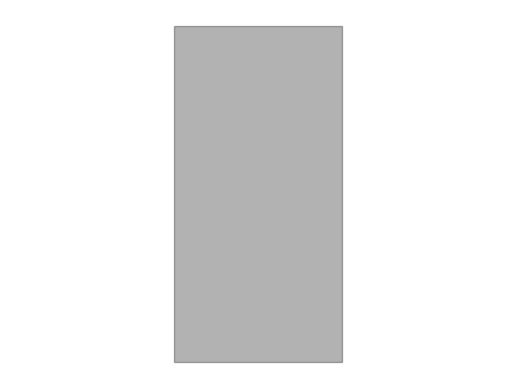

<Axes: >

In [3]:
soma_0.vis2d()

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


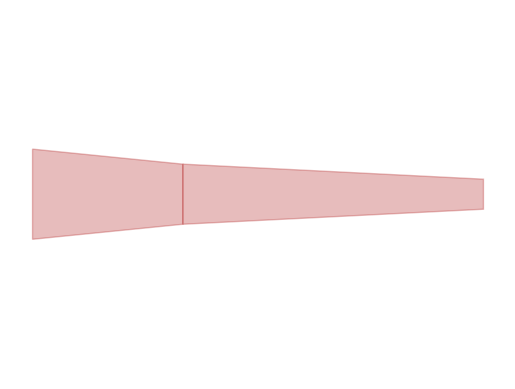

<Axes: >

In [4]:
basal_0.vis2d()

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


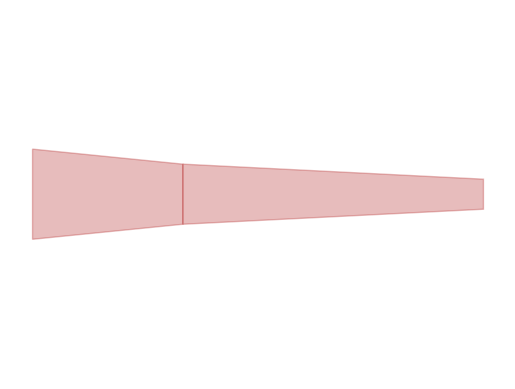

<Axes: >

In [5]:
basal_1.vis2d()

### Why keep both radius styles?

When radii stay continuous across segment boundaries, shared `radii=[r0, ..., rN]` is compact and easy to read.

When a branch contains a radius jump, the paired form is more explicit:

- use `radii_proximal` and `radii_distal` to describe the discontinuity directly
- the shared-radius form can still represent the same geometry, but it needs an extra zero-length segment at the jump

This behavior is intentional. Real morphology files sometimes contain coincident points with different radii to encode an abrupt diameter change, and `Branch` preserves that geometry.


In [6]:
jump_0 = Branch.from_lengths(
    lengths=[10.0, 20.0] * u.um,
    radii_proximal=[3.0, 2.0] * u.um,
    radii_distal=[1.0, 1.0] * u.um,
)
jump_1 = Branch.from_lengths(
    lengths=[10.0, 0.0, 20.0] * u.um,
    radii=[3.0, 1.0, 2.0, 1.0] * u.um,
)
print("jump_0 == jump_1:", jump_0 == jump_1)


jump_0 == jump_1: True


The table below summarizes the most useful `Branch` attributes. If a branch is created with `from_lengths(...)`, point-related fields are `None`. Use `from_points(...)` when later steps need spatial coordinates, such as spatial ranges, projections, or Euclidean distances.

| Attribute | Description |
| --- | --- |
| lengths | Length of each frustum segment (`N` values) |
| length | Total branch length |
| areas | Surface area of each segment (`N` values) |
| area | Total surface area of the branch |
| volumes | Volume of each segment (`N` values) |
| volume | Total branch volume |
| mean_radius | Length-weighted mean radius |
| radii_proximal | Proximal radius of each segment (`N` values) |
| radii_distal | Distal radius of each segment (`N` values) |
| radii | Radii at all shared nodes (`N + 1` values) when boundaries are continuous |
| points_proximal | Start point of each segment (`N` points) |
| points_distal | End point of each segment (`N` points) |
| points | Shared node coordinates (`N + 1` points) when point geometry is continuous |
| type | Branch type (`axon`, `dendrite`, `soma`, and related variants) |
| n_segments | Number of frustum segments |


In [7]:
# Reusable branches for the rest of the notebook
soma = Branch.from_lengths(
    lengths=[20.0] * u.um,
    radii=[10.0, 10.0] * u.um,
    type="soma",
)
basal = Branch.from_lengths(
    lengths=[40.0, 30.0] * u.um,
    radii=[2.0, 1.8, 1.2] * u.um,
    type="basal_dendrite",
)
apical = Branch.from_points(
    points=[(0.0, 0.0, 0.0), (15.0, 0.0, 0.0), (30.0, 5.0, 0.0)] * u.um,
    radii=[1.5, 1.2, 0.9] * u.um,
    type="apical_dendrite",
)
axon = Branch.from_points(
    points=[(-30.0, -5.0, 0.0), (-12.0, -2.0, 0.0), (-4.0, 0.0, 0.0)] * u.um,
    radii=[0.8, 0.9, 1.0] * u.um,
    type="axon",
)

In [8]:
branch_to_df(soma)

,key,value
0,lengths,[20. um]
1,radii_proximal,[10. um]
2,radii_distal,[10. um]
3,points_proximal,None
4,points_distal,None
5,type,soma


In [9]:
branch_to_df(basal)

,key,value
0,lengths,"[40. um, 30. um]"
1,radii_proximal,"[2. um, 1.8 um]"
2,radii_distal,"[1.8 um, 1.2 um]"
3,points_proximal,None
4,points_distal,None
5,type,basal_dendrite


In [10]:
branch_to_df(apical)

,key,value
0,lengths,"[15. um, 15.811388 um]"
1,radii_proximal,"[1.5 um, 1.2 um]"
2,radii_distal,"[1.2 um, 0.9 um]"
3,points_proximal,"[[0. um, 0. um, 0. um], [15. um, 0. um, 0. um]]"
4,points_distal,"[[15. um, 0. um, 0. um], [30. um, 5. um, 0. um]]"
5,type,apical_dendrite


In [11]:
branch_to_df(axon)

,key,value
0,lengths,"[18.248287 um, 8.246211 um]"
1,radii_proximal,"[0.8 um, 0.9 um]"
2,radii_distal,"[0.9 um, 1. um]"
3,points_proximal,"[[-30. um, -5. um, 0. um], [-12. um, -2. um, 0..."
4,points_distal,"[[-12. um, -2. um, 0. um], [-4. um, 0. um, 0. ..."
5,type,axon


## 2. `Morpho` / `MorphoBranch`: tree construction, attachment, and naming

`Morpho` owns the whole editable tree. `MorphoBranch` is a tree-local view of one branch, so it exposes branch geometry together with parent/child relationships.

This section demonstrates three common patterns:

- `Morpho.from_root(...)` to create the root branch
- `tree.soma.xxx = branch` syntax sugar for child attachment
- `tree.attach(...)` or `tree.soma[0.5, 1.0].xxx = branch` for explicit `parent_x` / `child_x`

Notes:

- `parent_x` must be one of `0`, `0.5`, or `1`
- `parent_x = 0.5` is only allowed when the parent branch type is `soma`
- `child_x` currently accepts only `0` or `1`
- if you do not provide an explicit child name, `Morpho` auto-generates one as `type_N`


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


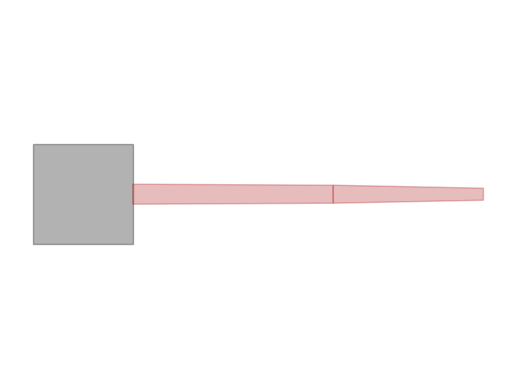

<Axes: >

In [12]:
# Start from the root branch
tree = Morpho.from_root(soma, name="soma")

# Syntax sugar: the attribute name becomes the child branch name
tree.soma.basal_slot = basal

tree.vis2d(mode='frustum')

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


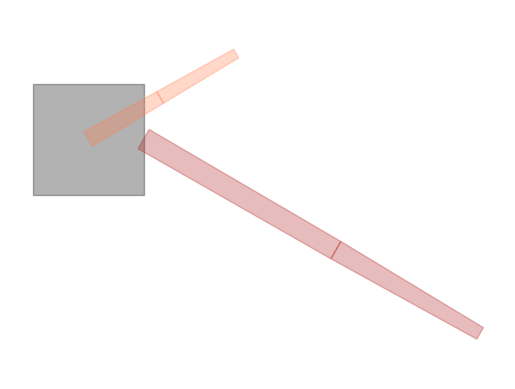

<Axes: >

In [13]:
# Explicit attach: without child_name, Morpho allocates type_N automatically
tree.attach(parent="soma", child_branch=apical, parent_x=0.5)

tree.vis2d(mode='frustum')

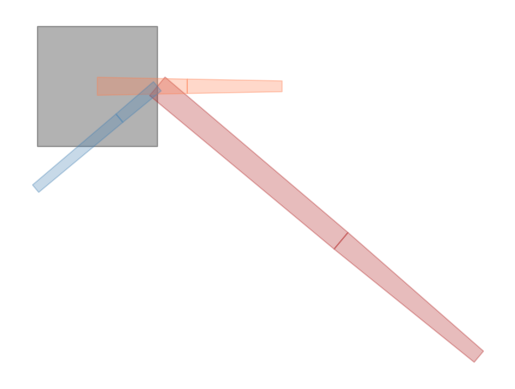

<Axes: >

In [14]:
# Attachment-point syntax makes parent_x and child_x visible at the call site
tree.soma[1.0, 1.0].axon_back = axon

tree.vis2d(mode='frustum')

In [15]:
print(tree.topo())

soma
├── basal_slot
├── apical_dendrite_0
└── axon_back


In [16]:
morpho_summary_df(tree)

,key,value
0,root_name,soma
1,root_type,soma
2,n_branches,4
3,n_stems,3
4,n_bifurcations,1
5,max_branch_order,1
6,total_length,147.3059 um
7,total_area,2395.2427 um^2
8,total_volume,7158.3784 um^3
9,mean_radius,2.5877914 um


In [17]:
morpho_branches_df(tree)

,index,name,type,parent,parent_x,child_x,n_children,length,has_points
0,0,soma,soma,None,NaN,NaN,3,20. um,False
1,1,basal_slot,basal_dendrite,soma,1.0,0.0,0,70. um,False
2,2,apical_dendrite_0,apical_dendrite,soma,0.5,0.0,0,30.811388 um,True
3,3,axon_back,axon,soma,1.0,1.0,0,26.4945 um,True


In [18]:
morpho_edges_df(tree)

,parent,child,parent_x,child_x
0,soma,basal_slot,1.0,0.0
1,soma,apical_dendrite_0,0.5,0.0
2,soma,axon_back,1.0,1.0


## 3. Queries, summaries, and tree-level metrics

Once the tree is built, `Morpho` supports structural queries, a compact summary helper, and derived metrics.

Common queries:

- `tree.branches`
- `tree.branches_by(order=...)`
- `tree.branch(name=...)`
- `tree.branch(index=..., order=...)`
- `tree.path_to_root(...)`
- `tree.summary()`

Common metrics:

- `n_branches` / `n_stems` / `n_bifurcations` / `max_branch_order`
- `total_length` / `total_area` / `total_volume` / `mean_radius`
- for trees with point geometry, `x_range / y_range / z_range` and distance-based metrics

`tree.summary()` is meant to stay compact even for larger morphologies, so it focuses on counts, aggregate geometry, and whether point-based distance metrics are available.

For coordinate-dependent metrics such as `x_range` and `max_euclidean_distance`, every terminal branch in the measured subtree should carry point geometry. The mixed tree above is fine for general metrics, but a fully point-based tree is better for spatial measurements.


In [19]:
morpho_branches_df(tree, order="default")

,index,name,type,parent,parent_x,child_x,n_children,length,has_points
0,0,soma,soma,None,NaN,NaN,3,20. um,False
1,1,basal_slot,basal_dendrite,soma,1.0,0.0,0,70. um,False
2,2,apical_dendrite_0,apical_dendrite,soma,0.5,0.0,0,30.811388 um,True
3,3,axon_back,axon,soma,1.0,1.0,0,26.4945 um,True


In [20]:
morpho_branches_df(tree, order="type")

,index,name,type,parent,parent_x,child_x,n_children,length,has_points
0,0,apical_dendrite_0,apical_dendrite,soma,0.5,0.0,0,30.811388 um,True
1,1,axon_back,axon,soma,1.0,1.0,0,26.4945 um,True
2,2,basal_slot,basal_dendrite,soma,1.0,0.0,0,70. um,False
3,3,soma,soma,None,NaN,NaN,3,20. um,False


In [21]:
morpho_branches_df(tree, order="depth")

,index,name,type,parent,parent_x,child_x,n_children,length,has_points
0,0,soma,soma,None,NaN,NaN,3,20. um,False
1,1,basal_slot,basal_dendrite,soma,1.0,0.0,0,70. um,False
2,2,apical_dendrite_0,apical_dendrite,soma,0.5,0.0,0,30.811388 um,True
3,3,axon_back,axon,soma,1.0,1.0,0,26.4945 um,True


In [22]:
apical_view = tree.branch(name="apical_dendrite_0")
dict_to_df(
    {
        "apical index": apical_view.index,
        "apical parent": apical_view.parent.name,
        "path_to_root(apical)": tree.path_to_root(apical_view.index),
    }
)

,key,value
0,apical index,2
1,apical parent,soma
2,path_to_root(apical),"(0, 2)"


In [23]:
morpho_summary_df(tree)

,key,value
0,root_name,soma
1,root_type,soma
2,n_branches,4
3,n_stems,3
4,n_bifurcations,1
5,max_branch_order,1
6,total_length,147.3059 um
7,total_area,2395.2427 um^2
8,total_volume,7158.3784 um^3
9,mean_radius,2.5877914 um


In [24]:
point_soma = Branch.from_points(
    points=[(0.0, 0.0, 0.0), (10.0, 0.0, 0.0)] * u.um,
    radii=[5.0, 5.0] * u.um,
    type="soma",
)
point_main = Branch.from_points(
    points=[(5.0, 0.0, 0.0), (5.0, 10.0, 0.0)] * u.um,
    radii=[2.0, 1.5] * u.um,
    type="basal_dendrite",
)
point_tuft = Branch.from_points(
    points=[(5.0, 10.0, 0.0), (5.0, 20.0, 0.0)] * u.um,
    radii=[1.5, 1.0] * u.um,
    type="apical_dendrite",
)
point_side = Branch.from_points(
    points=[(10.0, 0.0, 0.0), (12.0, 0.0, 0.0)] * u.um,
    radii=[1.0, 0.8] * u.um,
    type="axon",
)

point_tree = Morpho.from_root(point_soma, name="soma")
point_tree.soma.attach(point_main, name="main", parent_x=0.5)
point_tree.main.attach(point_tuft, name="tuft")
point_tree.soma.attach(point_side, name="side", parent_x=1.0)

morpho_summary_df(point_tree)

,key,value
0,root_name,soma
1,root_type,soma
2,n_branches,4
3,n_stems,2
4,n_bifurcations,1
5,max_branch_order,2
6,total_length,32. um
7,total_area,514.2564 um^2
8,total_volume,937.11615 um^3
9,mean_radius,2.55625 um


In [25]:
dict_to_df(
    {
        "x_range": point_tree.x_range,
        "y_range": point_tree.y_range,
        "z_range": point_tree.z_range,
        "max_path_distance": point_tree.max_path_distance,
        "max_euclidean_distance": point_tree.max_euclidean_distance,
    }
)

,key,value
0,x_range,12. um
1,y_range,20. um
2,z_range,0. um
3,max_path_distance,25. um
4,max_euclidean_distance,20.615528 um


## 4. `SWC` import: recommended entry point and report

`Morpho.from_swc(...)` is the main file-import entry point.

You can load just the tree:

- `tree = Morpho.from_swc(path)`

Or load the tree together with a structured reader report:

- `tree, report = Morpho.from_swc(path, return_report=True)`

The real SWC fixtures in this repository often produce warnings such as reordered nodes, renumbered indices, or contour detection. Those warnings usually describe normalization steps rather than fatal import failures.


In [26]:
repo_root = Path.cwd()
fixture_dir = repo_root / "morpho_files"
dict_to_df({"fixture_dir": fixture_dir})

,key,value
0,fixture_dir,D:\codes\projects\braincell\develop_doc\morpho...


In [27]:
swc_tree, swc_report = Morpho.from_swc(fixture_dir / "io.swc", return_report=True)

morpho_summary_df(swc_tree)

,key,value
0,root_name,soma
1,root_type,soma
2,n_branches,31
3,n_stems,6
4,n_bifurcations,11
5,max_branch_order,5
6,total_length,2600.9934 um
7,total_area,23262.256 um^2
8,total_volume,19080.898 um^3
9,mean_radius,1.4109921 um


In [28]:
morpho_report_summary_df(swc_report)

,key,value
0,n_issues,3
1,n_errors,0
2,n_warnings,3
3,has_errors,False
4,has_warnings,True
5,issue_codes,"(identity.sequential_index, semantics.contour,..."


In [29]:
morpho_report_df(swc_report).head(10)

,severity,code,message,line_number,node_id,fix_message,fix_applied
0,warning,semantics.contour,Soma samples were interpreted as a contour and...,None,None,None,False
1,warning,topology.sorted_order,SWC rows were reordered so parents appear befo...,None,None,sort rows into parent-before-child order,True
2,warning,identity.sequential_index,SWC node ids were renumbered to a sequential 1...,None,None,renumber indices sequentially,True


In [30]:
print("topology preview:")
print("\n".join(swc_tree.topo().splitlines()[:8]))

topology preview:
soma
├── soma_0
│   ├── basal_dendrite_11
│   │   ├── basal_dendrite_12
│   │   └── basal_dendrite_13
│   └── basal_dendrite_14
├── soma_1
├── soma_2


If you want a fixture with more visible warnings, load `bc.swc`.

This file triggers warnings for duplicate `xyzr` samples and unknown node types, but the reader can still normalize it into a usable `Morpho`.


In [31]:
warn_tree, warn_report = Morpho.from_swc(fixture_dir / "bc.swc", return_report=True)

morpho_summary_df(warn_tree)

,key,value
0,root_name,soma
1,root_type,soma
2,n_branches,114
3,n_stems,7
4,n_bifurcations,53
5,max_branch_order,12
6,total_length,2540.412 um
7,total_area,4389.4956 um^2
8,total_volume,796.3158 um^3
9,mean_radius,0.2723951 um


In [32]:
morpho_report_summary_df(warn_report)

,key,value
0,n_issues,103
1,n_errors,0
2,n_warnings,103
3,has_errors,False
4,has_warnings,True
5,issue_codes,"(geometry.duplicate_xyzr_node, identity.sequen..."


In [33]:
morpho_report_df(warn_report).head(10)

,severity,code,message,line_number,node_id,fix_message,fix_applied
0,warning,semantics.unknown_type,SWC type code 6 is not mapped. Using 0 (custom).,3188.0,3188.0,set type id to 0,True
1,warning,semantics.unknown_type,SWC type code 6 is not mapped. Using 0 (custom).,3189.0,3189.0,set type id to 0,True
2,warning,semantics.unknown_type,SWC type code 6 is not mapped. Using 0 (custom).,3190.0,3190.0,set type id to 0,True
3,warning,semantics.unknown_type,SWC type code 6 is not mapped. Using 0 (custom).,3191.0,3191.0,set type id to 0,True
4,warning,semantics.unknown_type,SWC type code 6 is not mapped. Using 0 (custom).,3192.0,3192.0,set type id to 0,True
5,warning,semantics.unknown_type,SWC type code 6 is not mapped. Using 0 (custom).,3193.0,3193.0,set type id to 0,True
6,warning,semantics.unknown_type,SWC type code 6 is not mapped. Using 0 (custom).,3194.0,3194.0,set type id to 0,True
7,warning,semantics.unknown_type,SWC type code 6 is not mapped. Using 0 (custom).,3195.0,3195.0,set type id to 0,True
8,warning,semantics.unknown_type,SWC type code 6 is not mapped. Using 0 (custom).,3196.0,3196.0,set type id to 0,True
9,warning,semantics.unknown_type,SWC type code 6 is not mapped. Using 0 (custom).,3197.0,3197.0,set type id to 0,True


## 5. `ASC`: minimal working example

The `ASC` entry point mirrors `SWC`:

- `tree = Morpho.from_asc(path)`
- `tree, report = Morpho.from_asc(path, return_report=True)`

This section only checks that the current reader builds a `Morpho` successfully; it does not dive into the parsing rules.


In [ ]:
asc_tree, asc_report = Morpho.from_asc(fixture_dir / "goc.asc", return_report=True)

morpho_summary_df(asc_tree)

D:\codes\projects\braincell\braincell\vis\backend_pyvista.py:83: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  viewer = plotter.show(


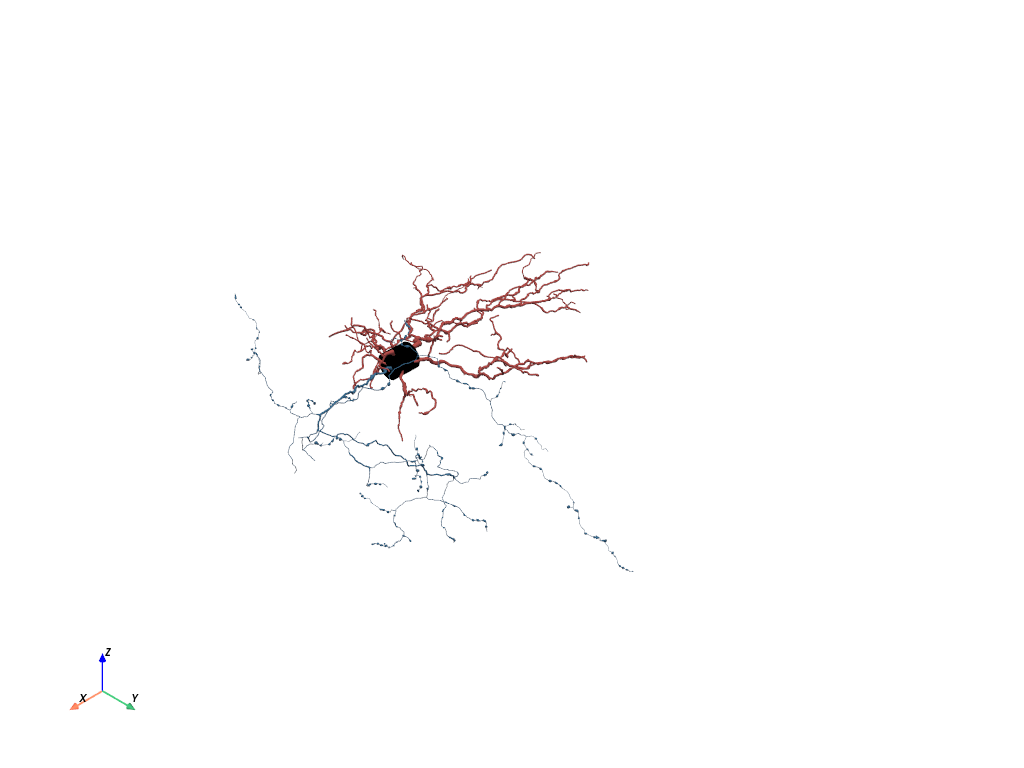

In [47]:
asc_tree.vis3d(jupyter_backend='html')

In [ ]:
morpho_report_summary_df(asc_report)

In [ ]:
morpho_report_df(asc_report).head(10)

In [37]:
print("topology preview:")
print("\n".join(asc_tree.topo().splitlines()[:8]))

topology preview:
soma
├── axon_0
│   ├── axon_1
│   │   ├── axon_2
│   │   │   ├── axon_3
│   │   │   │   ├── axon_4
│   │   │   │   │   ├── axon_5
│   │   │   │   │   │   ├── axon_6


## 6. Side-by-side example: `example_tree.swc`

For a fuller example, the next two cells build the same morphology in two ways: manually with `Branch` + `Morpho`, and by importing `example_tree.swc`.

At the moment this fixture imports as a small tree with 9 branches:

- `soma`
- `basal_dendrite_0` to `basal_dendrite_5`
- `axon_0`, `axon_1`

The reader may emit warnings about sparse samples, index reordering, or topology sorting, but those warnings do not block construction of the final `Morpho`.


In [38]:
manual_soma = Branch.from_points(
    points=[(-5.0, 0.0, 0.0), (0.0, 0.0, 0.0), (5.0, 0.0, 0.0)] * u.um,
    radii=[5.0, 5.0, 5.0] * u.um,
    type="soma",
)
manual_tree = Morpho.from_root(manual_soma, name="soma")

manual_tree.soma[0.5].basal_dendrite_0 = Branch.from_points(
    points=[(0.0, 20.0, 0.0), (-5.0, 40.0, 10.0), (-5.0, 55.0, 10.0)] * u.um,
    radii=[1.8, 1.4, 1.2] * u.um,
    type="basal_dendrite",
)
manual_tree.basal_dendrite_0[0.0].basal_dendrite_1 = Branch.from_points(
    points=[(0.0, 20.0, 0.0), (10.0, 30.0, 10.0), (15.0, 40.0, 10.0)] * u.um,
    radii=[1.8, 1.4, 1.4] * u.um,
    type="basal_dendrite",
)
manual_tree.basal_dendrite_1[1.0].basal_dendrite_2 = Branch.from_points(
    points=[(15.0, 40.0, 10.0), (30.0, 55.0, 0.0)] * u.um,
    radii=[1.4, 1.0] * u.um,
    type="basal_dendrite",
)
manual_tree.basal_dendrite_1[1.0].basal_dendrite_3 = Branch.from_points(
    points=[(15.0, 40.0, 10.0), (20.0, 45.0, 20.0)] * u.um,
    radii=[1.4, 1.4] * u.um,
    type="basal_dendrite",
)
manual_tree.basal_dendrite_0[1.0].basal_dendrite_4 = Branch.from_points(
    points=[(-5.0, 55.0, 10.0), (-5.0, 60.0, 20.0), (0.0, 70.0, 30.0)] * u.um,
    radii=[1.2, 1.0, 1.0] * u.um,
    type="basal_dendrite",
)
manual_tree.basal_dendrite_0[1.0].basal_dendrite_5 = Branch.from_points(
    points=[(-5.0, 55.0, 10.0), (0.0, 70.0, 0.0)] * u.um,
    radii=[1.2, 0.8] * u.um,
    type="basal_dendrite",
)
manual_tree.soma[0.5].axon_0 = Branch.from_points(
    points=[(5.0, -20.0, 20.0), (12.0, -20.0, 22.0)] * u.um,
    radii=[1.0, 1.0] * u.um,
    type="axon",
)
manual_tree.axon_0[0.0].axon_1 = Branch.from_points(
    points=[(5.0, -20.0, 20.0), (0.0, -30.0, 30.0)] * u.um,
    radii=[1.0, 0.8] * u.um,
    type="axon",
)

print("manual_tree topo:")
print(manual_tree.topo())

manual_tree topo:
soma
├── basal_dendrite_0
│   ├── basal_dendrite_1
│   │   ├── basal_dendrite_2
│   │   └── basal_dendrite_3
│   ├── basal_dendrite_4
│   └── basal_dendrite_5
└── axon_0
    └── axon_1


In [39]:
morpho_summary_df(manual_tree)

,key,value
0,root_name,soma
1,root_type,soma
2,n_branches,9
3,n_stems,2
4,n_bifurcations,3
5,max_branch_order,3
6,total_length,179.282 um
7,total_area,1643.8562 um^2
8,total_volume,1652.2874 um^3
9,mean_radius,1.4591627 um


In [40]:
morpho_branches_df(manual_tree)

,index,name,type,parent,parent_x,child_x,n_children,length,has_points
0,0,soma,soma,None,NaN,NaN,2,10. um,True
1,1,basal_dendrite_0,basal_dendrite,soma,0.5,0.0,3,37.91288 um,True
2,2,basal_dendrite_1,basal_dendrite,basal_dendrite_0,0.0,0.0,2,28.500849 um,True
3,3,basal_dendrite_2,basal_dendrite,basal_dendrite_1,1.0,0.0,0,23.452078 um,True
4,4,basal_dendrite_3,basal_dendrite,basal_dendrite_1,1.0,0.0,0,12.247449 um,True
5,5,basal_dendrite_4,basal_dendrite,basal_dendrite_0,1.0,0.0,0,26.18034 um,True
6,6,basal_dendrite_5,basal_dendrite,basal_dendrite_0,1.0,0.0,0,18.708286 um,True
7,7,axon_0,axon,soma,0.5,0.0,1,7.28011 um,True
8,8,axon_1,axon,axon_0,0.0,0.0,0,15. um,True


In [41]:
example_path = fixture_dir / "example_tree.swc"
example_tree, example_report = Morpho.from_swc(example_path, return_report=True)

morpho_summary_df(example_tree)

,key,value
0,root_name,soma
1,root_type,soma
2,n_branches,9
3,n_stems,2
4,n_bifurcations,3
5,max_branch_order,3
6,total_length,179.282 um
7,total_area,1643.8562 um^2
8,total_volume,1652.2874 um^3
9,mean_radius,1.4591627 um


In [42]:
morpho_report_summary_df(example_report)

,key,value
0,n_issues,3
1,n_errors,0
2,n_warnings,3
3,has_errors,False
4,has_warnings,True
5,issue_codes,"(format.low_sample_count, identity.sequential_..."


In [43]:
morpho_report_df(example_report).head(10)

,severity,code,message,line_number,node_id,fix_message,fix_applied
0,warning,format.low_sample_count,SWC contains only 14 samples; morphology may b...,None,None,None,False
1,warning,topology.sorted_order,SWC rows were reordered so parents appear befo...,None,None,sort rows into parent-before-child order,True
2,warning,identity.sequential_index,SWC node ids were renumbered to a sequential 1...,None,None,renumber indices sequentially,True


In [44]:
print("example_tree topo:")
print(example_tree.topo())

example_tree topo:
soma
├── basal_dendrite_0
│   ├── basal_dendrite_1
│   │   ├── basal_dendrite_2
│   │   └── basal_dendrite_3
│   ├── basal_dendrite_4
│   └── basal_dendrite_5
└── axon_0
    └── axon_1


In [45]:
morpho_compare_df(manual_tree, example_tree, names=("manual", "example"))

,key,manual,example,match
0,same_tree,None,None,True
1,same_topology,None,None,True
2,n_branches,9,9,True
3,max_branch_order,3,3,True
4,total_length,179.282 um,179.282 um,True
5,max_path_distance,69.093216 um,69.093216 um,True


## 7. Summary

At this point you have seen the main entry points in the current `morpho` layer:

- build geometry with `Branch.from_lengths(...)` and `Branch.from_points(...)`
- organize a full tree with `Morpho.from_root(...)`, syntax sugar attachment, and `attach(...)`
- query structure with `branch(...)`, `branches_by(...)`, `path_to_root(...)`, and tree metrics
- import real morphologies with `Morpho.from_swc(...)` and `Morpho.from_asc(...)`
- compare manual construction against file import with `example_tree.swc`

If you want to continue:

- for more file-format semantics, read `develop_doc/io.md`
- for how morphology becomes a discrete cell view, read `develop_doc/cell.ipynb`
